# Synthetic Bark Beetle ↔ Real Harvest Correlation

Validates the synthetic population model by measuring how well `bark_beetle_count`
predicts the real `target` (kubikov, m³ harvested) from `heatmap.csv`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

# ── Load ──────────────────────────────────────────────────────────────────────
beetle = pd.read_csv("../data/synthetic/bark_beetle_population.csv")
beetle["ggo"] = beetle["ggo"].astype(str)

target = pd.read_csv("../data/processed/heatmap.csv")
target["ggo"] = target["ggo"].astype(str)
target = target.rename(columns={"odsek_id": "odsek"})

# ── Join on (ggo, odsek, leto_mesec) ─────────────────────────────────────────
df = beetle.merge(target[["ggo", "odsek", "leto_mesec", "target"]],
                  on=["ggo", "odsek", "leto_mesec"], how="inner")
df = df[df["target"].notna() & (df["target"] > 0)].copy()
df["log_beetle"] = np.log1p(df["bark_beetle_count"])
df["log_target"] = np.log1p(df["target"])
df["month"] = df["leto_mesec"].str[5:7].astype(int)

print(f"Joined rows: {len(df):,}  |  Parcels: {df[['ggo','odsek']].drop_duplicates().shape[0]:,}")
print(df[["bark_beetle_count", "target"]].describe().round(1))

Joined rows: 310,375  |  Parcels: 34,348
       bark_beetle_count    target
count           310375.0  310375.0
mean               606.3      45.8
std                844.2     103.1
min                  0.0       0.0
25%                  0.0       6.4
50%                325.0      17.7
75%                864.0      45.1
max              30306.0    4374.8


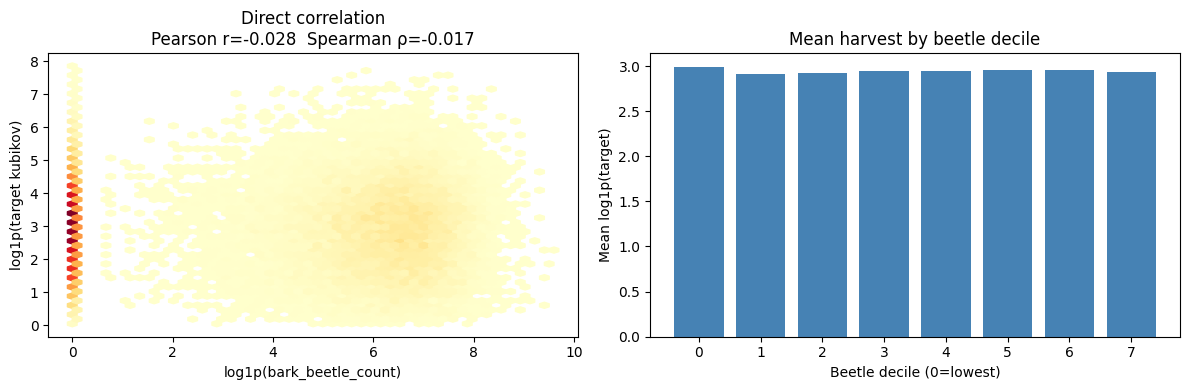

Pearson r = -0.0278  |  Spearman ρ = -0.0166


In [2]:
# ── 1. Scatter: log beetle vs log target ─────────────────────────────────────
samp = df.sample(min(30_000, len(df)), random_state=42)
pr, _ = stats.pearsonr(samp["log_beetle"], samp["log_target"])
sr, _ = stats.spearmanr(samp["log_beetle"], samp["log_target"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scatter
ax = axes[0]
ax.hexbin(samp["log_beetle"], samp["log_target"], gridsize=50, cmap="YlOrRd", mincnt=1)
ax.set_xlabel("log1p(bark_beetle_count)")
ax.set_ylabel("log1p(target kubikov)")
ax.set_title(f"Direct correlation\nPearson r={pr:.3f}  Spearman ρ={sr:.3f}")

# Binned mean (deciles)
ax2 = axes[1]
df["beetle_decile"] = pd.qcut(df["log_beetle"], 10, labels=False, duplicates="drop")
binned = df.groupby("beetle_decile")["log_target"].mean()
ax2.bar(binned.index, binned.values, color="steelblue")
ax2.set_xlabel("Beetle decile (0=lowest)")
ax2.set_ylabel("Mean log1p(target)")
ax2.set_title("Mean harvest by beetle decile")

plt.tight_layout()
plt.show()
print(f"Pearson r = {pr:.4f}  |  Spearman ρ = {sr:.4f}")

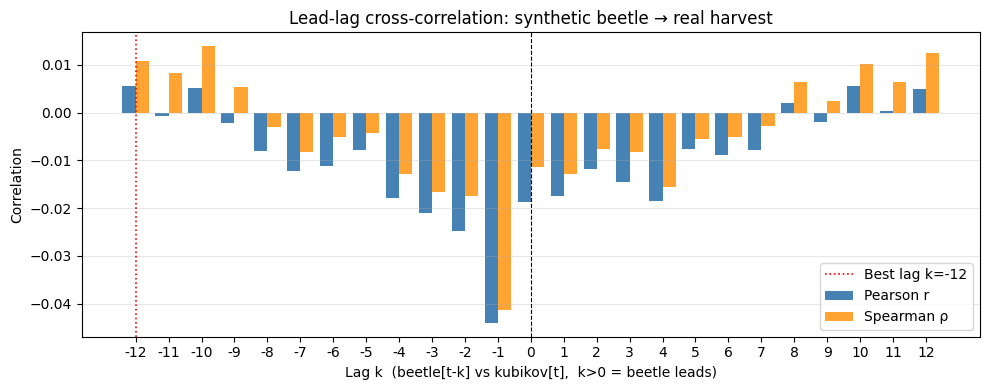

Peak Pearson r=0.0057 at lag k=-12 months


In [3]:
# ── 2. Lead-lag cross-correlation (beetle leads harvest?) ────────────────────
parcel_list = df[["ggo", "odsek"]].drop_duplicates().sample(8_000, random_state=42)
cc = (df.merge(parcel_list, on=["ggo","odsek"])
        .sort_values(["ggo","odsek","leto_mesec"])
        .copy())

LAG_RANGE = range(-12, 13)
pearson_rs, spearman_rs = [], []
for k in LAG_RANGE:
    shifted = cc.groupby(["ggo","odsek"])["log_beetle"].shift(k)
    mask = cc["log_target"].notna() & shifted.notna()
    pr, _ = stats.pearsonr(cc.loc[mask, "log_target"], shifted[mask])
    sr, _ = stats.spearmanr(cc.loc[mask, "log_target"], shifted[mask])
    pearson_rs.append(pr)
    spearman_rs.append(sr)

lags = list(LAG_RANGE)
best_k = lags[np.argmax(pearson_rs)]

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(lags))
ax.bar(x - 0.2, pearson_rs, 0.4, label="Pearson r", color="steelblue")
ax.bar(x + 0.2, spearman_rs, 0.4, label="Spearman ρ", color="darkorange", alpha=0.8)
ax.axvline(x=lags.index(0), color="black", linestyle="--", linewidth=0.8)
ax.axvline(x=lags.index(best_k), color="red", linestyle=":", linewidth=1.2,
           label=f"Best lag k={best_k}")
ax.set_xticks(x); ax.set_xticklabels(lags)
ax.set_xlabel("Lag k  (beetle[t-k] vs kubikov[t],  k>0 = beetle leads)")
ax.set_ylabel("Correlation")
ax.set_title("Lead-lag cross-correlation: synthetic beetle → real harvest")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()
print(f"Peak Pearson r={max(pearson_rs):.4f} at lag k={best_k} months")

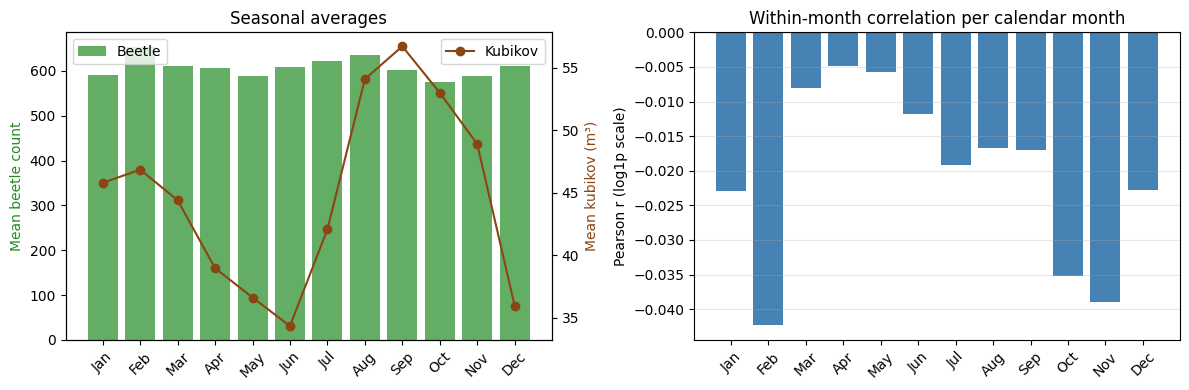

In [4]:
# ── 3. Seasonality & monthly correlation ─────────────────────────────────────
monthly_beetle = df.groupby("month")["bark_beetle_count"].mean()
monthly_target = df.groupby("month")["target"].mean()

# Per-month Pearson r
month_r = df.groupby("month").apply(
    lambda g: stats.pearsonr(g["log_beetle"], g["log_target"])[0]
    if len(g) > 10 else np.nan
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
months = np.arange(1, 13)
labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

ax1 = axes[0]
ax1b = ax1.twinx()
ax1.bar(months, monthly_beetle.values, color="forestgreen", alpha=0.7, label="Beetle")
ax1b.plot(months, monthly_target.values, "o-", color="saddlebrown", label="Kubikov")
ax1.set_xticks(months); ax1.set_xticklabels(labels, rotation=45)
ax1.set_ylabel("Mean beetle count", color="forestgreen")
ax1b.set_ylabel("Mean kubikov (m³)", color="saddlebrown")
ax1.set_title("Seasonal averages")
ax1.legend(loc="upper left"); ax1b.legend(loc="upper right")

ax2 = axes[1]
ax2.bar(months, month_r.values, color="steelblue")
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_xticks(months); ax2.set_xticklabels(labels, rotation=45)
ax2.set_ylabel("Pearson r (log1p scale)")
ax2.set_title("Within-month correlation per calendar month")
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout(); plt.show()

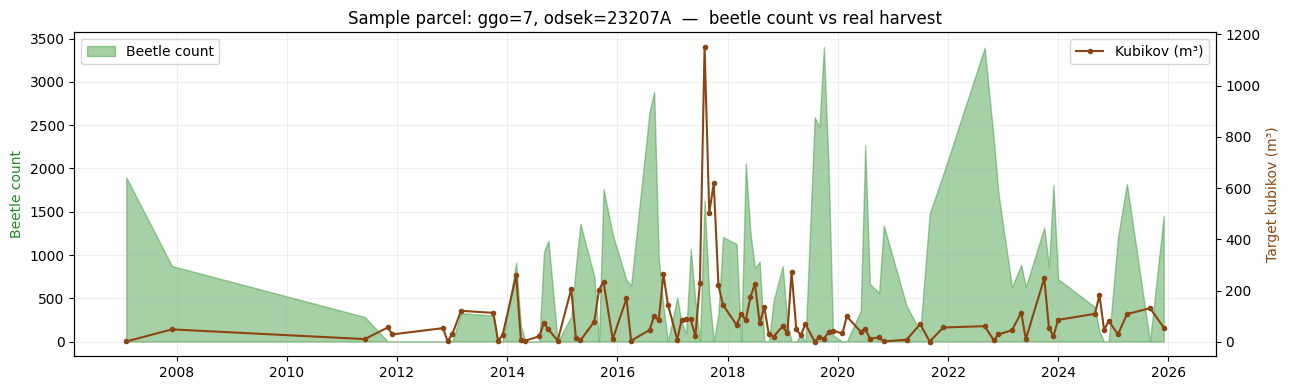

In [5]:
# ── 4. Sample parcel: beetle vs kubikov over time ────────────────────────────
# Pick a parcel with a reasonable amount of non-zero harvest
sample_key = (
    df[df["target"] > 0]
    .groupby(["ggo","odsek"])["target"].count()
    .sort_values(ascending=False)
    .index[5]
)
g, o = sample_key
parcel = df[(df["ggo"] == g) & (df["odsek"] == o)].sort_values("leto_mesec")
dates = pd.to_datetime(parcel["leto_mesec"])

fig, ax1 = plt.subplots(figsize=(13, 4))
ax2 = ax1.twinx()
ax1.fill_between(dates, parcel["bark_beetle_count"], alpha=0.4, color="forestgreen", label="Beetle count")
ax2.plot(dates, parcel["target"], "o-", color="saddlebrown", markersize=3, label="Kubikov (m³)")
ax1.set_ylabel("Beetle count", color="forestgreen")
ax2.set_ylabel("Target kubikov (m³)", color="saddlebrown")
ax1.set_title(f"Sample parcel: ggo={g}, odsek={o}  —  beetle count vs real harvest")
ax1.legend(loc="upper left"); ax2.legend(loc="upper right")
ax1.grid(alpha=0.2)
plt.tight_layout(); plt.show()